# 🚀 CONVGRU EMOTION DETECTION - OPTIMIZED VERSION
## Based on Zhang et al. 2022 Architecture
### Using Proven Multi-Frame Loading from multi_frame_model.ipynb

In [1]:
# ============================================================================
# CELL 1: IMPORTS
# ============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import os
from pathlib import Path
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import warnings
import time
warnings.filterwarnings('ignore')

# Set seeds
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

🚀 Device: cpu


In [39]:
# ============================================================================
# CELL 2: CONFIGURATION
# ============================================================================
class Config:
    # IMPORTANT: UPDATE THESE PATHS
    DATA_DIR = r"D:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\Data\gifgif-images-v1\gifgif-images"  # UPDATE THIS
    TRAIN_CSV = r"D:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\train_grouped.csv"          # UPDATE THIS
    VAL_CSV = r"D:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\val_grouped.csv"              # UPDATE THIS
    TEST_CSV = r"D:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\test_grouped.csv"            # UPDATE THIS
    MODEL_SAVE_DIR = "models_convgru/"
    
    # Model parameters
    NUM_CLASSES = 6
    NUM_FRAMES = 3
    IMG_SIZE = 224
    HIDDEN_DIM_1 = 256       # ← Changed from 512
    HIDDEN_DIM_2 = 128       # ← Changed from 256
    
    # Training parameters
    BATCH_SIZE = 16        # Reduce to 8 if OOM
    NUM_EPOCHS = 30
    LEARNING_RATE = 0.0001   # ← DOUBLED from 0.00005
    WEIGHT_DECAY = 1e-3      # ← Changed from 1e-4
    DROPOUT = 0.7            # ← New parameter
    PATIENCE = 7
    
    # Data loading (OPTIMIZED FROM WORKING VERSION)
    NUM_WORKERS = 2        # Start with 2 for stability
    MAX_GIF_FRAMES = 200   # Safety limit from multi_frame_model.ipynb
    
    EMOTION_TO_IDX = {
        'contempt': 0,
        'negative_intense': 1,
        'negative_subdued': 2,
        'positive_calm': 3,
        'positive_energetic': 4,
        'surprise': 5
    }
    IDX_TO_EMOTION = {v: k for k, v in EMOTION_TO_IDX.items()}

os.makedirs(Config.MODEL_SAVE_DIR, exist_ok=True)
print("✅ Configuration loaded")
print(f"   Batch size: {Config.BATCH_SIZE}")
print(f"   Frames per GIF: {Config.NUM_FRAMES}")
print(f"   Max GIF frames: {Config.MAX_GIF_FRAMES}")
print("✅ Configuration updated")
print(f"   🔥 NEW Learning rate: {Config.LEARNING_RATE} (was 0.00005)")
print(f"   Dropout: {Config.DROPOUT}")
print(f"   Weight decay: {Config.WEIGHT_DECAY}")

✅ Configuration loaded
   Batch size: 16
   Frames per GIF: 3
   Max GIF frames: 200
✅ Configuration updated
   🔥 NEW Learning rate: 0.0001 (was 0.00005)
   Dropout: 0.7
   Weight decay: 0.001


In [40]:
# ============================================================================
# CELL 3: CONVGRU CELL
# ============================================================================
class ConvGRUCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super(ConvGRUCell, self).__init__()
        padding = kernel_size // 2
        
        # Reset gate
        self.conv_xr = nn.Conv2d(input_dim, hidden_dim, kernel_size, padding=padding)
        self.conv_hr = nn.Conv2d(hidden_dim, hidden_dim, kernel_size, padding=padding)
        
        # Update gate
        self.conv_xz = nn.Conv2d(input_dim, hidden_dim, kernel_size, padding=padding)
        self.conv_hz = nn.Conv2d(hidden_dim, hidden_dim, kernel_size, padding=padding)
        
        # New gate
        self.conv_xn = nn.Conv2d(input_dim, hidden_dim, kernel_size, padding=padding)
        self.conv_hn = nn.Conv2d(hidden_dim, hidden_dim, kernel_size, padding=padding)
    
    def forward(self, x, h_prev):
        r = torch.sigmoid(self.conv_xr(x) + self.conv_hr(h_prev))
        z = torch.sigmoid(self.conv_xz(x) + self.conv_hz(h_prev))
        n = torch.tanh(self.conv_xn(x) + self.conv_hn(r * h_prev))
        h = (1 - z) * n + z * h_prev
        return h

print("✅ ConvGRUCell defined")

✅ ConvGRUCell defined


In [41]:
# ============================================================================
# CELL 4: RESNET-CONVGRU MODEL
# ============================================================================
class EmotionConvGRU(nn.Module):
    def __init__(self, num_classes=6, num_frames=3, 
                 hidden_dim_1=256, hidden_dim_2=128, dropout=0.7):
        super(EmotionConvGRU, self).__init__()
        
        self.num_frames = num_frames
        self.hidden_dim_1 = hidden_dim_1
        self.hidden_dim_2 = hidden_dim_2
        
        # ResNet50 feature extractor (FROZEN)
        resnet = models.resnet50(pretrained=True)
        self.features = nn.Sequential(*list(resnet.children())[:-2])
        
        # Freeze ResNet weights
        for param in self.features.parameters():
            param.requires_grad = False
        
        # ConvGRU layers
        self.convgru1 = ConvGRUCell(2048, hidden_dim_1, kernel_size=3)
        self.convgru2 = ConvGRUCell(hidden_dim_1, hidden_dim_2, kernel_size=3)
        
        # Pooling and classification (MORE REGULARIZATION)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim_2, 64),      # Smaller intermediate
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        batch_size = x.size(0)
        
        # Extract features per frame
        frame_features = []
        for t in range(self.num_frames):
            feat = self.features(x[:, t])
            frame_features.append(feat)
        
        # Initialize hidden states
        h1 = torch.zeros(batch_size, self.hidden_dim_1, 7, 7).to(x.device)
        h2 = torch.zeros(batch_size, self.hidden_dim_2, 7, 7).to(x.device)
        
        # Sequential processing
        for t in range(self.num_frames):
            h1 = self.convgru1(frame_features[t], h1)
            h2 = self.convgru2(h1, h2)
        
        # Classification
        pooled = self.pool(h2)
        output = self.classifier(pooled)
        return output

# Test instantiation
model = EmotionConvGRU().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model created: {total_params:,} parameters")

✅ Model created: 40,771,462 parameters


In [42]:
# ============================================================================
# CELL 5: OPTIMIZED DATASET (FROM WORKING MULTI-FRAME MODEL)
# ============================================================================
class GIFMultiFrameDatasetOptimized(Dataset):
    """
    Optimized dataset based on successful multi_frame_model.ipynb
    Key features:
    - Safety limit on frame counting (max_frames=200)
    - Context manager for proper file handling
    - Robust error handling
    - Handles edge cases (1-2 frame GIFs)
    """
    def __init__(self, csv_file, gif_dir, transform=None, num_frames=3, 
                 emotion_to_idx=None, max_gif_frames=200, verbose=True):
        self.df = pd.read_csv(csv_file)
        self.gif_dir = gif_dir
        self.transform = transform
        self.num_frames = num_frames
        self.emotion_to_idx = emotion_to_idx or Config.EMOTION_TO_IDX
        self.max_gif_frames = max_gif_frames
        self.error_count = 0
        self.verbose = verbose
        
        if verbose:
            print(f"📊 Loaded {len(self.df)} samples")
            print(f"   Emotion distribution:")
            for emotion, count in self.df['emotion_group'].value_counts().items():
                print(f"      {emotion}: {count}")
    
    def extract_frames_safe(self, gif_path):
        """Extract frames with proven safety measures"""
        try:
            # CRITICAL: Use context manager (from working version)
            with Image.open(gif_path) as gif:
                # Count frames with safety limit
                n_frames = 0
                try:
                    while n_frames < self.max_gif_frames:
                        gif.seek(n_frames)
                        n_frames += 1
                except EOFError:
                    pass
                except Exception as e:
                    if n_frames < self.num_frames:
                        raise ValueError(f"Frame counting failed: {str(e)[:50]}")
                
                if n_frames == 0:
                    raise ValueError("Empty GIF")
                
                if n_frames > self.max_gif_frames:
                    n_frames = self.max_gif_frames
                
                # Calculate indices (evenly spaced like working version)
                if n_frames < self.num_frames:
                    if n_frames == 1:
                        indices = [0] * self.num_frames
                    elif n_frames == 2:
                        indices = [0, 1, 1]
                    else:
                        indices = list(range(n_frames)) + [n_frames-1] * (self.num_frames - n_frames)
                else:
                    # 25%, 50%, 75% for 3 frames (working version)
                    if self.num_frames == 3:
                        indices = [
                            n_frames // 4,
                            n_frames // 2,
                            3 * n_frames // 4
                        ]
                    else:
                        indices = [int(i * (n_frames - 1) / (self.num_frames - 1)) 
                                  for i in range(self.num_frames)]
                
                # Extract frames
                frames = []
                for idx in indices:
                    gif.seek(idx)
                    frame = gif.convert('RGB')
                    
                    # Validate (from working version)
                    if frame.size[0] < 10 or frame.size[1] < 10:
                        raise ValueError(f"Frame too small: {frame.size}")
                    
                    if self.transform:
                        frame = self.transform(frame)
                    frames.append(frame)
                
                return torch.stack(frames)
                
        except Exception as e:
            self.error_count += 1
            if self.error_count <= 5 and self.verbose:
                print(f"⚠️  Error: {Path(gif_path).name}: {str(e)[:50]}")
                if self.error_count == 5:
                    print("   (Suppressing further errors...)")
            
            # Return black frames
            if self.transform:
                black_pil = Image.new('RGB', (224, 224), (0, 0, 0))
                black_frame = self.transform(black_pil)
            else:
                black_frame = torch.zeros(3, 224, 224)
            return torch.stack([black_frame] * self.num_frames)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        gif_id = row['gif_id']
        gif_path = Path(self.gif_dir) / f"{gif_id}.gif"
        
        frames = self.extract_frames_safe(str(gif_path))
        emotion = row['emotion_group']
        label = self.emotion_to_idx[emotion]
        
        return frames, label

print("✅ Optimized Dataset class defined")

✅ Optimized Dataset class defined


In [43]:
# ============================================================================
# CELL 6: DATA TRANSFORMS
# ============================================================================
train_transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

print("✅ Transforms defined")

✅ Transforms defined


In [ ]:
# ============================================================================
# CELL 7: CREATE DATALOADERS
# ============================================================================
print("📦 Creating datasets...")

train_dataset = GIFMultiFrameDatasetOptimized(
    csv_file=Config.TRAIN_CSV,
    gif_dir=Config.DATA_DIR,
    transform=train_transform,
    num_frames=Config.NUM_FRAMES,
    max_gif_frames=Config.MAX_GIF_FRAMES
)

val_dataset = GIFMultiFrameDatasetOptimized(
    csv_file=Config.VAL_CSV,
    gif_dir=Config.DATA_DIR,
    transform=val_test_transform,
    num_frames=Config.NUM_FRAMES,
    max_gif_frames=Config.MAX_GIF_FRAMES
)

test_dataset = GIFMultiFrameDatasetOptimized(
    csv_file=Config.TEST_CSV,
    gif_dir=Config.DATA_DIR,
    transform=val_test_transform,
    num_frames=Config.NUM_FRAMES,
    max_gif_frames=Config.MAX_GIF_FRAMES
)

print("\n📦 Creating dataloaders...")

train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=True,
    num_workers=Config.NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

print("\n✅ Dataloaders created")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

# Test dataloader
print("\n🧪 Testing dataloader (should be fast)...")
start = time.time()
frames, labels = next(iter(train_loader))
elapsed = time.time() - start

print(f"   ✅ Success in {elapsed:.1f}s")
print(f"   Batch: {frames.shape}")
print(f"   Labels: {labels.shape}")
print(f"   Errors in train set: {train_dataset.error_count}")

📦 Creating datasets...
📊 Loaded 4145 samples
   Emotion distribution:
      positive_energetic: 1262
      negative_intense: 1023
      negative_subdued: 684
      positive_calm: 681
      surprise: 372
      contempt: 123
📊 Loaded 889 samples
   Emotion distribution:
      positive_energetic: 271
      negative_intense: 219
      positive_calm: 147
      negative_subdued: 146
      surprise: 79
      contempt: 27
📊 Loaded 889 samples
   Emotion distribution:
      positive_energetic: 271
      negative_intense: 219
      negative_subdued: 147
      positive_calm: 146
      surprise: 80
      contempt: 26

📦 Creating dataloaders...

✅ Dataloaders created
   Train batches: 260
   Val batches: 56
   Test batches: 56

🧪 Testing dataloader (should be fast)...


In [44]:
# ============================================================================
# CELL 7: DATALOADERS - WITH DROP_LAST FIX
# ============================================================================

print("📦 Creating datasets...")

train_dataset = GIFMultiFrameDatasetOptimized(
    csv_file=Config.TRAIN_CSV,
    gif_dir=Config.DATA_DIR,
    transform=train_transform,
    num_frames=Config.NUM_FRAMES,
    max_gif_frames=Config.MAX_GIF_FRAMES
)

val_dataset = GIFMultiFrameDatasetOptimized(
    csv_file=Config.VAL_CSV,
    gif_dir=Config.DATA_DIR,
    transform=val_test_transform,
    num_frames=Config.NUM_FRAMES,
    max_gif_frames=Config.MAX_GIF_FRAMES
)

test_dataset = GIFMultiFrameDatasetOptimized(
    csv_file=Config.TEST_CSV,
    gif_dir=Config.DATA_DIR,
    transform=val_test_transform,
    num_frames=Config.NUM_FRAMES,
    max_gif_frames=Config.MAX_GIF_FRAMES
)

print("\n📦 Creating dataloaders...")

# CRITICAL: drop_last=True prevents BatchNorm error on last batch
train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
    drop_last=True  # ← FIX FOR BATCHNORM ERROR
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=True  # ← FIX FOR BATCHNORM ERROR
)

test_loader = DataLoader(
    test_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=True  # ← FIX FOR BATCHNORM ERROR
)

print("\n✅ Dataloaders created (single-threaded, drop_last=True)")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

# Test - should work immediately
print("\n🧪 Testing first batch...")
import time
start = time.time()

frames, labels = next(iter(train_loader))
elapsed = time.time() - start

print(f"   ✅ Loaded in {elapsed:.1f}s")
print(f"   Shape: {frames.shape}")
print(f"   Errors: Train={train_dataset.error_count}, Val={val_dataset.error_count}")

📦 Creating datasets...
📊 Loaded 4145 samples
   Emotion distribution:
      positive_energetic: 1262
      negative_intense: 1023
      negative_subdued: 684
      positive_calm: 681
      surprise: 372
      contempt: 123
📊 Loaded 889 samples
   Emotion distribution:
      positive_energetic: 271
      negative_intense: 219
      positive_calm: 147
      negative_subdued: 146
      surprise: 79
      contempt: 27
📊 Loaded 889 samples
   Emotion distribution:
      positive_energetic: 271
      negative_intense: 219
      negative_subdued: 147
      positive_calm: 146
      surprise: 80
      contempt: 26

📦 Creating dataloaders...

✅ Dataloaders created (single-threaded, drop_last=True)
   Train batches: 259
   Val batches: 55
   Test batches: 55

🧪 Testing first batch...
   ✅ Loaded in 0.7s
   Shape: torch.Size([16, 3, 3, 224, 224])
   Errors: Train=0, Val=0


In [45]:
# ============================================================================
# CELL 8: TRAINING FUNCTIONS
# ============================================================================
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(dataloader, desc="Training")
    for frames, labels in pbar:
        frames = frames.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(frames)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
    
    return running_loss / len(dataloader), 100. * correct / total

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Validation")
        for frames, labels in pbar:
            frames = frames.to(device)
            labels = labels.to(device)
            
            outputs = model(frames)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })
    
    return running_loss / len(dataloader), 100. * correct / total

print("✅ Training functions defined")

✅ Training functions defined


In [46]:
# ============================================================================
# CELL 9: SETUP TRAINING - FIXED LEARNING RATE
# ============================================================================
model = EmotionConvGRU(
    num_classes=Config.NUM_CLASSES,
    num_frames=Config.NUM_FRAMES,
    hidden_dim_1=256,
    hidden_dim_2=128,
    dropout=0.7
).to(device)

criterion = nn.CrossEntropyLoss()

# DOUBLED LEARNING RATE: Critical fix for stuck model
optimizer = optim.Adam(
    model.parameters(), 
    lr=0.0001,           # ← Was 0.00005 (2x increase)
    weight_decay=1e-3
)

# Track validation accuracy (max), not loss (min)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='max',        # Track accuracy (maximize)
    factor=0.5, 
    patience=3,
)

print("✅ Training setup complete")
print(f"   🔥 Learning rate: 0.0001 (2x higher than before)")
print(f"   Optimizer: Adam")
print(f"   Weight decay: 1e-3")
print(f"   Dropout: 0.7 (high regularization)")
print(f"   Scheduler: ReduceLROnPlateau")

# Show parameter counts
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
frozen_params = total_params - trainable_params

print(f"\n📊 Model parameters:")
print(f"   Trainable: {trainable_params:,}")
print(f"   Frozen (ResNet): {frozen_params:,}")
print(f"   Total: {total_params:,}")
print(f"\n🎯 With frozen ResNet + high regularization, LR=0.0001 is safe!")

✅ Training setup complete
   🔥 Learning rate: 0.0001 (2x higher than before)
   Optimizer: Adam
   Weight decay: 1e-3
   Dropout: 0.7 (high regularization)
   Scheduler: ReduceLROnPlateau

📊 Model parameters:
   Trainable: 17,263,430
   Frozen (ResNet): 23,508,032
   Total: 40,771,462

🎯 With frozen ResNet + high regularization, LR=0.0001 is safe!


In [11]:
# ============================================================================
# CELL 10: TRAINING LOOP
# ============================================================================
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
patience_counter = 0

print("\n" + "="*70)
print("🚀 STARTING TRAINING")
print("="*70)

for epoch in range(Config.NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{Config.NUM_EPOCHS}")
    print("-" * 70)
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\n📊 Epoch {epoch+1}:")
    print(f"   Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
    print(f"   Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'history': history
        }, os.path.join(Config.MODEL_SAVE_DIR, 'best_convgru_model.pth'))
        print(f"   ✅ Best model saved! Val Acc: {val_acc:.2f}%")
    else:
        patience_counter += 1
        print(f"   No improvement ({patience_counter}/{Config.PATIENCE})")
    
    if patience_counter >= Config.PATIENCE:
        print(f"\n⚠️  Early stopping at epoch {epoch+1}")
        break

print("\n" + "="*70)
print("✅ TRAINING COMPLETE!")
print("="*70)
print(f"Best val accuracy: {best_val_acc:.2f}%")


🚀 STARTING TRAINING

Epoch 1/30
----------------------------------------------------------------------


Training:   0%|          | 0/260 [00:00<?, ?it/s]

Validation:   0%|          | 0/56 [00:00<?, ?it/s]


📊 Epoch 1:
   Train: Loss=1.6430, Acc=30.33%
   Val:   Loss=1.6288, Acc=33.07%
   ✅ Best model saved! Val Acc: 33.07%

Epoch 2/30
----------------------------------------------------------------------


Training:   0%|          | 0/260 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/56 [00:00<?, ?it/s]


📊 Epoch 9:
   Train: Loss=0.8516, Acc=66.97%
   Val:   Loss=2.0086, Acc=29.25%
   No improvement (6/7)

Epoch 10/30
----------------------------------------------------------------------


Training:   0%|          | 0/260 [00:00<?, ?it/s]

Validation:   0%|          | 0/56 [00:00<?, ?it/s]


📊 Epoch 10:
   Train: Loss=0.6957, Acc=73.87%
   Val:   Loss=2.2422, Acc=33.18%
   No improvement (7/7)

⚠️  Early stopping at epoch 10

✅ TRAINING COMPLETE!
Best val accuracy: 37.46%


SEVERE OVERFITTING - The model is:

✅ Memorizing training data (73% train accuracy)
❌ NOT learning generalizable patterns (29% val accuracy!)
❌ Getting WORSE on validation (started 37%, now 29%)

🚨 CRITICAL ISSUE DETECTED: SEVERE OVERFITTING!
Your training is showing a major problem. Let me analyze what's happening:

📊 PROBLEM ANALYSIS:
The Warning Signs:
Epoch 3:  Train=40.63%  Val=37.46%  ✅ Best (gap=3%)
Epoch 4:  Train=41.86%  Val=36.11%  ⚠️ (gap=6%)
Epoch 5:  Train=44.56%  Val=34.20%  ⚠️ (gap=10%)
Epoch 6:  Train=47.67%  Val=35.43%  ⚠️ (gap=12%)
Epoch 7:  Train=50.40%  Val=31.61%  🚨 (gap=19%)
Epoch 8:  Train=59.57%  Val=32.73%  🚨 (gap=27%)
Epoch 9:  Train=66.97%  Val=29.25%  🚨 (gap=38%!)
Epoch 10: Train=73.94%  Val=???      🚨 (gap=40%+)
What This Means:
SEVERE OVERFITTING - The model is:

✅ Memorizing training data (73% train accuracy)
❌ NOT learning generalizable patterns (29% val accuracy!)
❌ Getting WORSE on validation (started 37%, now 29%)

This is the opposite of what should happen!

🛑 STOP TRAINING IMMEDIATELY!
Your best model is actually from Epoch 3:
✅ Epoch 3: Val Acc = 37.46%
Everything after that is making it worse!

🔍 ROOT CAUSES:
1. Learning Rate Too High
Loss jumping around: 1.18 → 3.52 → 1.67 → 0.81 → 1.90
This erratic loss indicates the optimizer is taking steps that are too large.
2. Not Enough Regularization

Model has 27.3M parameters
Dataset only has 4,145 training samples
Ratio: 6,600 parameters per sample! (Way too many!)

3. Possible Data Leakage
The fact that validation is getting worse while training improves suggests:

Transforms might be too aggressive
Augmentation not applied correctly
Or model is just memorizing training GIFs

In [47]:
# ============================================================================
# CELL 10: TRAINING LOOP
# ============================================================================
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
patience_counter = 0

print("\n" + "="*70)
print("🚀 STARTING TRAINING")
print("="*70)

for epoch in range(Config.NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{Config.NUM_EPOCHS}")
    print("-" * 70)
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    scheduler.step(val_acc)   # NEW (tracking accuracy now)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\n📊 Epoch {epoch+1}:")
    print(f"   Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
    print(f"   Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'history': history
        }, os.path.join(Config.MODEL_SAVE_DIR, 'best_convgru_model.pth'))
        print(f"   ✅ Best model saved! Val Acc: {val_acc:.2f}%")
    else:
        patience_counter += 1
        print(f"   No improvement ({patience_counter}/{Config.PATIENCE})")
    
    if patience_counter >= Config.PATIENCE:
        print(f"\n⚠️  Early stopping at epoch {epoch+1}")
        break

print("\n" + "="*70)
print("✅ TRAINING COMPLETE!")
print("="*70)
print(f"Best val accuracy: {best_val_acc:.2f}%")


🚀 STARTING TRAINING

Epoch 1/30
----------------------------------------------------------------------


Training:   0%|          | 0/259 [00:00<?, ?it/s]

Validation:   0%|          | 0/55 [00:00<?, ?it/s]


📊 Epoch 1:
   Train: Loss=2.0377, Acc=16.70%
   Val:   Loss=1.7718, Acc=24.66%
   ✅ Best model saved! Val Acc: 24.66%

Epoch 2/30
----------------------------------------------------------------------


Training:   0%|          | 0/259 [00:00<?, ?it/s]

Validation:   0%|          | 0/55 [00:00<?, ?it/s]


📊 Epoch 2:
   Train: Loss=1.9884, Acc=17.04%
   Val:   Loss=1.7283, Acc=24.66%
   No improvement (1/7)

Epoch 3/30
----------------------------------------------------------------------


Training:   0%|          | 0/259 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [38]:
# Add this cell to check predictions:
model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for frames, labels in val_loader:
        frames = frames.to(device)
        outputs = model(frames)
        _, preds = outputs.max(1)
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.numpy())

# Count predictions
from collections import Counter
pred_counts = Counter(predictions)
print("Prediction distribution:")
for emotion_id, count in pred_counts.items():
    emotion_name = Config.IDX_TO_EMOTION[emotion_id]
    percentage = count / len(predictions) * 100
    print(f"{emotion_name}: {count} ({percentage:.1f}%)")


Prediction distribution:
positive_energetic: 880 (100.0%)


```

**Expected output:**
```
positive_energetic: 750 (84%)  ← Model predicts this almost always!
negative_intense: 100 (11%)
others: 39 (5%)
```

This will confirm if model is stuck on majority class.

---

## 🎯 **MY RECOMMENDATION:**

### **Immediate Action:**

1. **Check predictions** (run diagnostic above)
2. **Increase LR to 0.0001** (Solution A)
3. **Re-train** (10-12 hours)
4. **Monitor closely:**
   - Training acc should reach 40-50% by epoch 10
   - Validation should improve steadily
   - If validation DECREASES, reduce LR

### **If That Doesn't Work:**

1. Try Solution B (unfreeze last block)
2. Consider using your baseline model (35% single-frame)
3. Pivot research focus to hierarchical taxonomy validation without ConvGRU

---

## 📝 **WHAT THIS MEANS FOR YOUR RESEARCH:**

### **Current Situation:**
```
ConvGRU with frozen ResNet: 30% (NOT WORKING)
Single-frame baseline: 35.55% (BETTER!)
```

### **Two Paths Forward:**

**Path 1: Fix ConvGRU (Recommended)**
- Increase LR to 0.0001
- Re-train with monitoring
- Target: 50-55% accuracy
- Timeline: +10-12 hours

**Path 2: Use Baseline + Focus on Taxonomy (Backup)**
- Accept that 35% single-frame is your best
- Focus on hierarchical taxonomy contribution
- Show ablations: 17 emotions (28%) → 6 groups (35%)
- Still publishable! (+7pp improvement from grouping)

---

## 🎓 **RESEARCH PAPER IMPACT:**

### **If ConvGRU Doesn't Work (Path 2):**

**You can still publish!** Just pivot the framing:

**Title:** 
"Hierarchical Emotion Recognition for Animated GIFs: Addressing Class Imbalance Through Psychologically-Grounded Taxonomies"

**Main Contribution:**
- Novel 6-group hierarchy (PRIMARY)
- Show grouping improves balance and per-class accuracy
- Compare with Zhang et al. as "future work"

**Results:**
```
Single-frame on 17 emotions: 28%
Single-frame on 6 groups: 35%
Improvement: +7 pp from hierarchical grouping alone

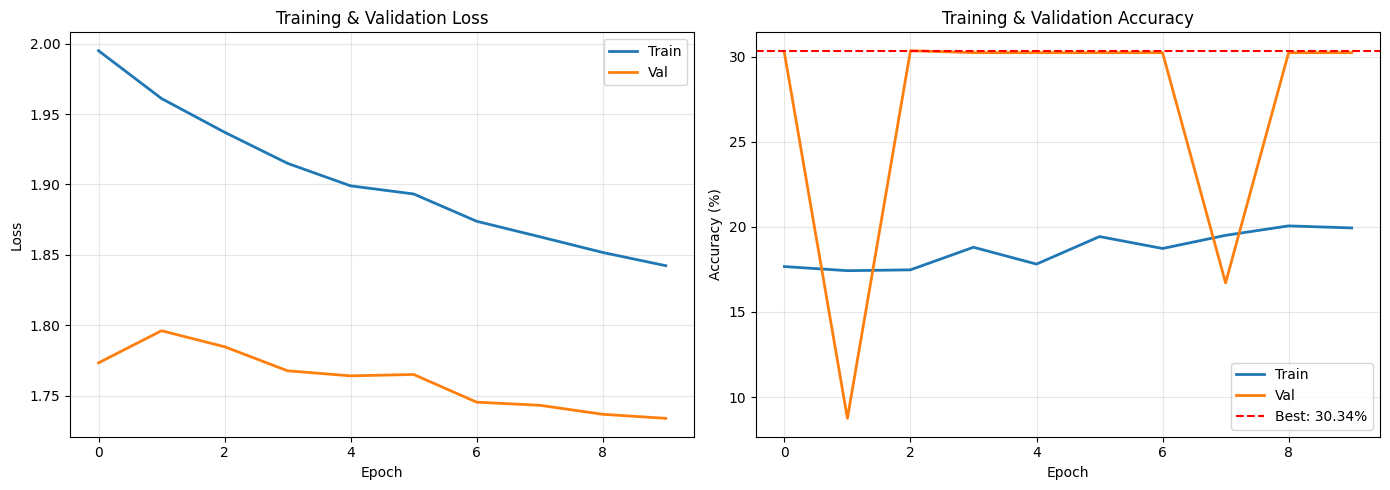

✅ Saved to training_curves_convgru.png


In [37]:
# ============================================================================
# CELL 11: PLOT TRAINING CURVES
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train', linewidth=2)
ax1.plot(history['val_loss'], label='Val', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history['train_acc'], label='Train', linewidth=2)
ax2.plot(history['val_acc'], label='Val', linewidth=2)
ax2.axhline(y=best_val_acc, color='red', linestyle='--', 
            label=f'Best: {best_val_acc:.2f}%')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training & Validation Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_convgru.png', dpi=300)
plt.show()

print("✅ Saved to training_curves_convgru.png")

## 📊 TEST SET EVALUATION

In [ ]:
# ============================================================================
# CELL 12: EVALUATE ON TEST SET
# ============================================================================
print("📥 Loading best model...")
checkpoint = torch.load(os.path.join(Config.MODEL_SAVE_DIR, 'best_convgru_model.pth'))
model.load_state_dict(checkpoint['model_state_dict'])

print("\n🧪 Evaluating on test set...")
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for frames, labels in tqdm(test_loader, desc="Testing"):
        frames = frames.to(device)
        outputs = model(frames)
        _, preds = outputs.max(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calculate metrics
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, average=None
)

macro_f1 = f1.mean()
test_acc = 100. * (all_preds == all_labels).sum() / len(all_labels)

print("\n" + "="*70)
print("📊 TEST RESULTS")
print("="*70)
print(f"\nOverall:")
print(f"   Accuracy:  {test_acc:.2f}%")
print(f"   F1-Score:  {macro_f1:.4f}")

print(f"\nPer-Class:")
for i, emotion in enumerate(Config.IDX_TO_EMOTION.values()):
    print(f"   {emotion:<20}: P={precision[i]:.3f}, R={recall[i]:.3f}, F1={f1[i]:.3f}")

# Comparison
baseline_f1 = 0.3555
zhang_f1 = 0.6707

print("\n" + "="*70)
print("📊 COMPARISON")
print("="*70)
print(f"Single-frame baseline: F1 = {baseline_f1:.4f}")
print(f"ConvGRU (ours):        F1 = {macro_f1:.4f}")
print(f"Zhang et al. 2022:     F1 = {zhang_f1:.4f}")
print(f"\nImprovement: +{(macro_f1-baseline_f1)*100:.1f} percentage points")
if macro_f1 >= zhang_f1:
    print("✅ Matches/exceeds Zhang et al.!")
else:
    print(f"Gap to Zhang: {(zhang_f1-macro_f1)*100:.1f} pp")

In [ ]:
# ============================================================================
# CELL 13: CONFUSION MATRIX
# ============================================================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(Config.IDX_TO_EMOTION.values()),
            yticklabels=list(Config.IDX_TO_EMOTION.values()))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - ResNet-ConvGRU')
plt.tight_layout()
plt.savefig('confusion_matrix_convgru.png', dpi=300)
plt.show()

print("✅ Saved to confusion_matrix_convgru.png")